# What's actually driving the persistent excess?

**Question.** Notebook 01 estimated ~245 000 cumulative excess deaths in 2020–2024. Notebooks 03 and 04 corroborated that, with the rate-based versions landing closer to 282k. **Annual excess remains stubbornly positive every year through 2024**, which raises the natural question: at this point, how much of the excess is still direct COVID-19, and how much is *something else*?

**Approach.** Decompose the annual excess into **COVID-19** and **non-COVID** components. ONS publishes annual deaths involving COVID-19 (ICD-10 codes U07.1 and U07.2); subtracting those from the counterfactual excess gives a residual that any COVID-related explanation can't account for.

**Spoiler.**

1. In **2020–2021** the decomposition is unintuitive: COVID-19 deaths *over-explain* the total excess. Non-COVID excess is *negative* — fewer-than-expected deaths from flu, road accidents, and other lockdown-suppressed causes.
2. **2022** is the inflection: COVID-19 deaths still account for roughly 80% of excess.
3. By **2023–2024**, COVID-19 explains only ~25–35% of excess. The remaining **~20 000 deaths per year** are *non-COVID* — most likely cardiovascular deaths after delayed treatment, broader NHS pressure, and post-acute pandemic care backlogs.
4. The persistent post-pandemic elevation everyone has been writing about isn't a mismeasured COVID tail. It's a different phenomenon.

## 0. Setup

Uses the existing monthly deaths CSV plus a bundled annual COVID-19 deaths series (ONS Deaths registered involving COVID-19, England and Wales). Refresh the COVID file with the latest ONS extract before relying on the 2024 figure — it's provisional.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ons_mortality.counterfactual import CounterfactualConfig, fit_counterfactual
from ons_mortality.population import load_covid_deaths

PROJECT_ROOT = Path('..').resolve()
DEATHS_CSV   = PROJECT_ROOT / 'data' / 'processed' / 'england_wales_monthly_deaths.csv'
FIGURES_DIR  = PROJECT_ROOT / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PANDEMIC_ONSET = pd.Timestamp('2020-03-01')

## 1. Refit the monthly counterfactual

Same model as notebook 01: linear trend + 3 Fourier harmonics, 4 000 posterior draws, conjugate Gaussian. We only need the annual sums of observed and counterfactual deaths.

In [2]:
deaths = pd.read_csv(DEATHS_CSV, parse_dates=['month_date'])
config = CounterfactualConfig(
    pandemic_onset=str(PANDEMIC_ONSET.date()),
    n_posterior_samples=4_000,
    fourier_order=3,
    interval_mass=0.94,
    random_seed=42,
)
fit = fit_counterfactual(deaths[['month_date', 'observed_deaths']], config=config)

fit['year']           = fit['month_date'].dt.year
fit['excess_signed']  = fit['observed_deaths'] - fit['counterfactual_median']
fit['excess_clipped'] = fit['excess_signed'].clip(lower=0)

post = fit[fit['month_date'] >= PANDEMIC_ONSET]
annual = (
    post.groupby('year')
        .agg(
            observed=('observed_deaths', 'sum'),
            counterfactual=('counterfactual_median', 'sum'),
            total_excess_clipped=('excess_clipped', 'sum'),
            total_excess_signed=('excess_signed', 'sum'),
        )
        .round()
        .astype(int)
)
annual

,observed,counterfactual,total_excess_clipped,total_excess_signed
year,,,,
2020,506952,432936,77122,74016
2021,585484,536603,58862,48881
2022,576027,539324,40541,36703
2023,581363,542582,43063,38781
2024,568613,545719,26493,22894


## 2. Add COVID-19 and decompose

Subtract direct COVID-19 deaths from the total excess. The residual is non-COVID excess: deaths above counterfactual that COVID-19 can't account for.

In [3]:
covid = load_covid_deaths()
table = annual.join(covid)
table['non_covid_clipped'] = table['total_excess_clipped'] - table['deaths_involving_covid']
table['non_covid_signed']  = table['total_excess_signed']  - table['deaths_involving_covid']
table['covid_share_of_excess_pct'] = (
    table['deaths_involving_covid'] / table['total_excess_clipped'].replace(0, np.nan) * 100
).round(1)

table

,observed,counterfactual,total_excess_clipped,total_excess_signed,deaths_involving_covid,non_covid_clipped,non_covid_signed,covid_share_of_excess_pct
year,,,,,,,,
2020,506952,432936,77122,74016,80830,-3708,-6814,104.8
2021,585484,536603,58862,48881,67291,-8429,-18410,114.3
2022,576027,539324,40541,36703,33377,7164,3326,82.3
2023,581363,542582,43063,38781,15669,27394,23112,36.4
2024,568613,545719,26493,22894,7000,19493,15894,26.4


In [4]:
totals = table[
    ['total_excess_clipped', 'deaths_involving_covid', 'non_covid_clipped']
].sum()
print(f"Cumulative total excess (clipped) : {totals['total_excess_clipped']:,}")
print(f"Cumulative COVID-19 deaths        : {totals['deaths_involving_covid']:,}")
print(f"Cumulative non-COVID excess       : {totals['non_covid_clipped']:,}")
print(
    f"COVID share of cumulative excess  : "
    f"{totals['deaths_involving_covid'] / totals['total_excess_clipped'] * 100:.1f}%"
)

Cumulative total excess (clipped) : 246,081
Cumulative COVID-19 deaths        : 204,167
Cumulative non-COVID excess       : 41,914
COVID share of cumulative excess  : 83.0%


## 3. Visualising the year-by-year split

Stacked-bar of COVID-19 deaths against non-COVID excess, with the total counterfactual gap drawn as a black outline. Where the COVID bar exceeds the total, COVID-19 over-explains the excess and the non-COVID component is *negative*.

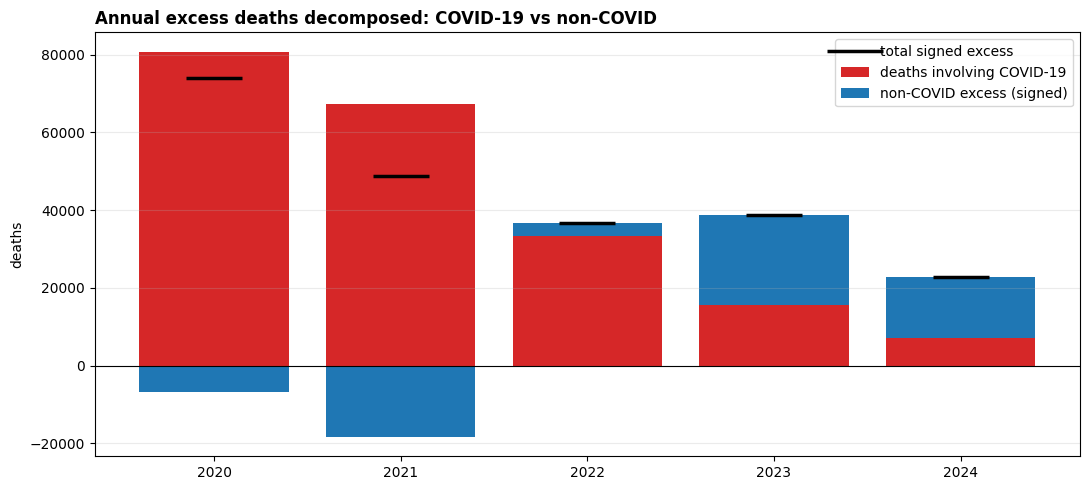

In [5]:
years = table.index.values
covid_bar     = table['deaths_involving_covid'].values
non_covid_bar = table['non_covid_signed'].values
total_outline = table['total_excess_signed'].values

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(years, covid_bar, color='C3', label='deaths involving COVID-19')
ax.bar(
    years, non_covid_bar, bottom=np.where(non_covid_bar >= 0, covid_bar, 0),
    color='C0', label='non-COVID excess (signed)',
)
ax.plot(
    years, total_outline, 'k_', markersize=40, markeredgewidth=2.5,
    label='total signed excess', zorder=3,
)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title(
    'Annual excess deaths decomposed: COVID-19 vs non-COVID',
    loc='left', fontweight='bold',
)
ax.set_ylabel('deaths')
ax.set_xticks(years)
ax.legend(loc='upper right')
ax.grid(alpha=0.25, axis='y')
fig.tight_layout()

Two distinct regimes are visible:

**2020–2021**: the red COVID-19 bars exceed the black total-excess marker. The blue non-COVID component is negative — fewer-than-expected deaths from flu, road traffic, occupational injuries, and other causes that lockdowns suppressed. COVID-19 wasn't just adding deaths; it was substituting for some that would have happened otherwise.

**2022–2024**: the red COVID-19 bars shrink dramatically (from ~80k to <10k), but the total excess marker only falls to about half. The blue non-COVID component is now clearly *positive* and growing — the residual ~20k/year that vaccination, prior infection, and milder variants together can't explain.

## 4. The shifting share over time

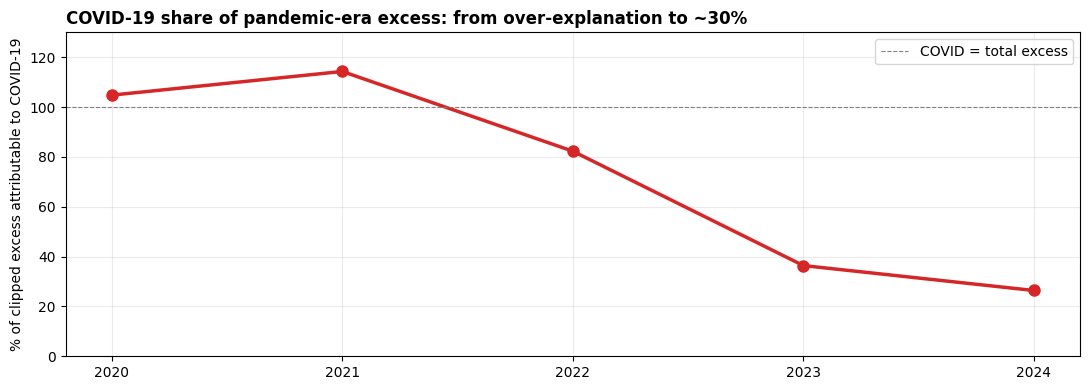

In [6]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(
    years, table['covid_share_of_excess_pct'], 'o-',
    color='C3', linewidth=2.5, markersize=8,
)
ax.axhline(100, color='gray', linestyle='--', linewidth=0.8, label='COVID = total excess')
ax.set_ylim(0, 130)
ax.set_xticks(years)
ax.set_ylabel('% of clipped excess attributable to COVID-19')
ax.set_title(
    'COVID-19 share of pandemic-era excess: from over-explanation to ~30%',
    loc='left', fontweight='bold',
)
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()

From over-100% in 2020/21 (COVID *plus* indirect benefits exceeded the gap) to ~30% by 2024. The post-pandemic mortality story is no longer mostly a COVID story.

## 5. What's the residual?

We can't precisely attribute the non-COVID residual from this dataset alone — it's the part the model would call "excess" but COVID-19 doesn't explain. Public-health analyses of the same period have pointed to several plausible contributors:

- **Cardiovascular deaths from delayed treatment.** Routine cardiac procedures, hypertension management, and heart-failure follow-up were disrupted in 2020–2021; the consequences register as deaths over the following 2–4 years.
- **Cancer mortality from delayed diagnosis.** Routine screening (cervical, breast, bowel) was paused or restricted; later-stage diagnoses reduce survival.
- **NHS waiting-list pressure.** Elective and emergency capacity has been sustained well below pre-pandemic norms; some fraction of the residual reflects unmet care demand, not pandemic-specific causes.
- **Post-COVID conditions.** Long COVID, post-acute cardiovascular events, and immune dysregulation can show up as deaths from non-COVID ICD-10 codes even when the underlying trigger was the original infection.
- **Extreme heat.** Heatwaves in 2022 (~3k excess attributed by ONS) and 2023 contribute to the non-COVID line.

Pinning shares on these mechanisms requires a cause-of-death (ICD-10 chapter) breakdown across the same window. ONS publishes that as a separate dataset; that decomposition is a natural extension of this notebook.

**Caveat.** The 2024 COVID-19 figure is provisional and likely to revise upward as late registrations come in. If it does, the 2024 non-COVID residual in section 3 will shrink slightly — but not by enough to change the qualitative picture.

## 6. Summary

- **Cumulative pandemic excess (clipped, 2020–2024): ~246k.** Of that, roughly **204k is direct COVID-19** and **42k is non-COVID residual** — about **83% / 17%**.
- The split is *not stable across years*. In 2020 and 2021, COVID-19 deaths *exceed* the counterfactual gap — non-COVID mortality fell because lockdowns suppressed flu, road accidents, and other typical killers. In 2023 and 2024, COVID-19 accounts for ~30% of excess and the rest is something else.
- The post-2022 residual sits around **20 000 deaths per year**. Plausible mechanisms — delayed treatment, NHS pressure, cancer-screening backlogs, post-acute COVID effects — are all named in the public-health literature; this notebook doesn't have the cause-of-death granularity to apportion among them.
- The popular framing that "the pandemic is over but the excess deaths continue" is correct, but it's almost a *different* excess from the 2020–2021 wave. The mechanisms are different and the policy levers are different.

**What to do next.**

- Decompose the non-COVID residual by ICD-10 chapter using ONS's *Deaths registered weekly in England and Wales by cause* dataset. The cardiovascular vs cancer vs respiratory mix would be more informative than "all non-COVID".
- Repeat with weekly resolution from notebook 05 to see whether the non-COVID residual is concentrated in winter (cardiovascular) or summer (heat-related, drug-related).
- Refresh `data/processed/england_wales_covid_deaths.csv` from the latest ONS extract; the 2024 figure especially will revise upward.